In [1]:
%load_ext autoreload
%autoreload 2
import os
print(os.getcwd())
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
import pickle
from utils import reproducibility
batch_size = 256
reproducibility(2025)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/disk1/user/liaoshuilin/project/35.TAPE_EXO/assay_diffusion


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Reading single-cell dataset, this may take 1 min
Index(['Adipose Tissue', 'Muscle', 'Heart', 'Thyroid', 'Kidney', 'Breast',
       'Skin', 'Salivary Gland', 'Adrenal Gland', 'Lung', 'Spleen', 'Pancreas',
       'Esophagus', 'Stomach', 'Colon', 'Small Intestine', 'Prostate',
       'Testis', 'Liver', 'Ovary', 'Bladder', 'Cervix Uteri',
       'Fallopian Tube'],
      dtype='object', name='Tissue')
Filtering dataset to only include tissues: ['Adipose Tissue', 'Muscle', 'Lung', 'Liver', 'Skin', 'Colon', 'Bladder', 'Kidney', 'Small Intestine', 'Esophagus']


/disk/user/liaoshuilin/software/anaconda3/envs/scGPCL/lib/python3.9/site-packages/anndata/utils.py:252: UserWarning: X converted to numpy array with dtype float64
  warnings.warn(f"{name} converted to numpy array with dtype {arr.dtype}")
/disk/user/liaoshuilin/software/anaconda3/envs/scGPCL/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Using prior info to generate cell fractions in Dirichlet distribution
Dirichlet cell fractions is generated
Sparse mode on, probability = 0.5


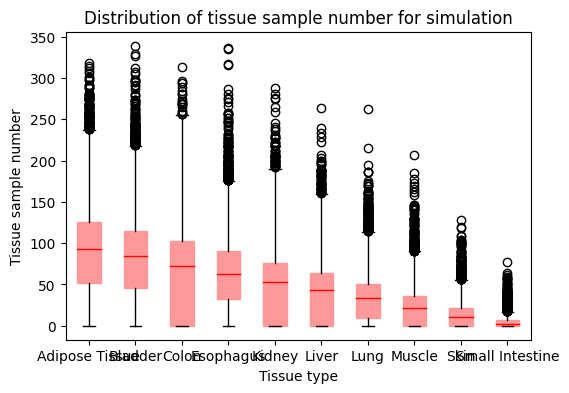

Sampling cells to compose pseudo-bulk data


100%|██████████| 5000/5000 [00:43<00:00, 113.98it/s]
/disk/user/liaoshuilin/software/anaconda3/envs/scGPCL/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Sampling is done
Reading single-cell dataset, this may take 1 min
Index(['Adipose Tissue', 'Adrenal Gland', 'Bladder', 'Breast', 'Cervix Uteri',
       'Colon', 'Esophagus', 'Fallopian Tube', 'Heart', 'Kidney', 'Liver',
       'Lung', 'Muscle', 'Ovary', 'Pancreas', 'Prostate', 'Salivary Gland',
       'Skin', 'Small Intestine', 'Spleen', 'Stomach', 'Testis', 'Thyroid'],
      dtype='object', name='Tissue')
Filtering dataset to only include tissues: ['Adipose Tissue', 'Muscle', 'Lung', 'Liver', 'Skin', 'Colon', 'Bladder', 'Kidney', 'Small Intestine', 'Esophagus']
Using prior info to generate cell fractions in Dirichlet distribution
Dirichlet cell fractions is generated
Sparse mode on, probability = 0.5


/disk/user/liaoshuilin/software/anaconda3/envs/scGPCL/lib/python3.9/site-packages/anndata/utils.py:252: UserWarning: X converted to numpy array with dtype float64
  warnings.warn(f"{name} converted to numpy array with dtype {arr.dtype}")
/disk/user/liaoshuilin/software/anaconda3/envs/scGPCL/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


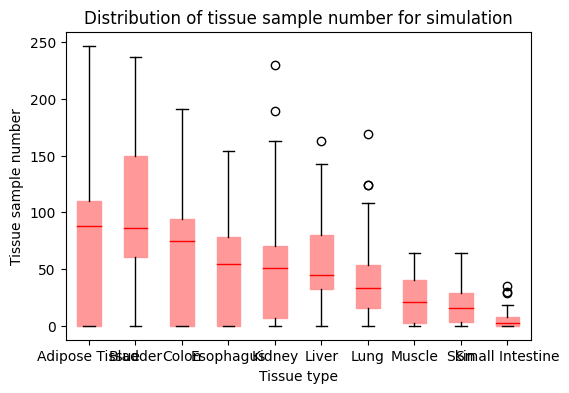

Sampling cells to compose pseudo-bulk data


100%|██████████| 50/50 [00:00<00:00, 163.63it/s]
/disk/user/liaoshuilin/software/anaconda3/envs/scGPCL/lib/python3.9/site-packages/anndata/_core/anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Sampling is done
(5000, 18757)
(50, 18757)
Scaling...
Using minmax scaler...
Scaling...
Using minmax scaler...
(5000, 18757)
(5000, 10)
(50, 18757)
(50, 10)
Scaling...
Using minmax scaler...
(664, 18757)


In [2]:
%load_ext autoreload
%autoreload 2
from data_process import generate_simulated_dataVarTiss, GTEDataGeneVar, GetXandYSelG, GetXandYSelGReal, DataSplitTrValTe

item = "T10C3"

Tis3 = ["Adipose Tissue", "Muscle", "Lung"]
Tis10 = ["Adipose Tissue", "Muscle", "Lung", "Liver", "Skin", "Colon", "Bladder", "Kidney", "Small Intestine", "Esophagus"]

if item == "T3C1":
    tissue_list = Tis3
    d_prior = [5, 3.5, 1.5]
elif item == "T3C2":
    tissue_list = Tis3
    d_prior = [3.5, 1.5, 5]
elif item == "T3C3":
    tissue_list = Tis3
    d_prior = [1.5, 5, 3.5]
elif item == "T10C1":
    tissue_list = Tis10
    d_prior = [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
elif item == "T10C2":
    tissue_list = Tis10
    d_prior = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
elif item == "T10C3":
    tissue_list = Tis10
    d_prior = [19, 17, 15, 13, 11, 9, 7, 5, 3, 1]

# 抽样仿真
simudata_GTE, label_GTE, cell_num_GTE, prop_GTE = generate_simulated_dataVarTiss(sc_data="../result/expr/dat1_gtex_tissue_tpm_filter.txt",
                                                         tissue_list=tissue_list, d_prior=d_prior,
                                                         n=500, samplenum=5000,
                                                         sparse=True, random_state=42)

simudata_HPA, label_HPA, cell_num_HPA, prop_HPA = generate_simulated_dataVarTiss(sc_data="../result/expr/dat1_hpa_tissue_tpm_filter.txt",
                                                         tissue_list=tissue_list, d_prior=d_prior,
                                                         n=500, samplenum=50,
                                                         sparse=True, random_state=42)

print(simudata_GTE.shape)
print(simudata_HPA.shape)

all_genename = GTEDataGeneVar(simudata_GTE, vart = False)
GTE_x, GTE_y, celltypes = GetXandYSelG(simudata_GTE, all_genename, scaler="mms") 
HPA_x, HPA_y, celltypes = GetXandYSelG(simudata_HPA, all_genename, scaler="mms") 
print(GTE_x.shape)
print(GTE_y.shape)
print(HPA_x.shape)
print(HPA_y.shape)

# real数据
real_pth = "../result/expr/all_exo_tpm_filter.txt"
real_x = GetXandYSelGReal(real_pth, all_genename, scaler="mms") 
print(real_x.shape)

# 数据拆分
GTE_x_train, GTE_x_val, GTE_x_test, GTE_y_train, GTE_y_val, GTE_y_test = DataSplitTrValTe(GTE_x, GTE_y)

# 数据保存
data_to_save = {

    'simudata_GTE': simudata_GTE,
    'label_GTE': list(label_GTE),
    'simudata_HPA': simudata_HPA,
    'label_HPA': list(label_HPA),
    'cell_num_GTE': cell_num_GTE,
    'prop_HPA': prop_HPA,
    'all_genename': all_genename,
    'celltypes': celltypes,

    'GTE_x': GTE_x,
    'GTE_y': GTE_y,
    'HPA_x': HPA_x,
    'HPA_y': HPA_y,
    'real_x': real_x,

    'GTE_x_train': GTE_x_train,
    'GTE_x_val': GTE_x_val,
    'GTE_x_test': GTE_x_test,
    'GTE_y_train': GTE_y_train,
    'GTE_y_val': GTE_y_val,
    'GTE_y_test': GTE_y_test,
}

with open(f'../result/data_variTiss/Stim_data_' + item + '.pkl', 'wb') as file:
    pickle.dump(data_to_save, file)

genename_df = pd.DataFrame(all_genename, columns=["GeneName"])
genename_df.to_csv(f'../result/data_variTiss/Stim_data_' + item + '_genename_sig.csv', index=False)

celltypes_df = pd.DataFrame(celltypes, columns=["TissueType"])
celltypes_df.to_csv(f'../result/data_variTiss/Stim_data_' + item + '_TissueType_sig.csv', index=False)

In [2]:
%load_ext autoreload
%autoreload 2
from utils import calculate_evaluation_metrics

item_values = ["T3C1", "T3C2", "T3C3", "T10C1", "T10C2", "T10C3"]

for item in item_values:
    out_pth = "/disk1/user/liaoshuilin/project/35.TAPE_EXO/result/data_variTiss/" + item + "_"
    print(out_pth)
    with open(f'../result/data_variTiss/Stim_data_' + item + '.pkl', 'rb') as file:
        loaded_data = pickle.load(file)
    GTE_x_train = loaded_data['GTE_x_train']
    print(GTE_x_train.shape)
    GTE_x_val = loaded_data['GTE_x_val']
    GTE_x_test = loaded_data['GTE_x_test']
    GTE_y_train = loaded_data['GTE_y_train']
    print(GTE_y_train.shape)
    GTE_y_val = loaded_data['GTE_y_val']
    GTE_y_test = loaded_data['GTE_y_test']
    HPA_x = loaded_data['HPA_x']
    HPA_y = loaded_data['HPA_y']
    print(HPA_x.shape)
    print(HPA_y.shape)

    # pd.DataFrame(GTE_y_test).to_csv(out_pth + 'GTE_real_y.csv', index=False, header=False)
    pd.DataFrame(HPA_y).to_csv(out_pth + 'HPA_real_y.csv', index=False, header=False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/disk1/user/liaoshuilin/project/35.TAPE_EXO/result/data_variTiss/T3C1_
(4000, 18757)
(4000, 3)
(50, 18757)
(50, 3)
/disk1/user/liaoshuilin/project/35.TAPE_EXO/result/data_variTiss/T3C2_
(4000, 18757)
(4000, 3)
(50, 18757)
(50, 3)
/disk1/user/liaoshuilin/project/35.TAPE_EXO/result/data_variTiss/T3C3_
(4000, 18757)
(4000, 3)
(50, 18757)
(50, 3)
/disk1/user/liaoshuilin/project/35.TAPE_EXO/result/data_variTiss/T10C1_
(4000, 18757)
(4000, 10)
(50, 18757)
(50, 10)
/disk1/user/liaoshuilin/project/35.TAPE_EXO/result/data_variTiss/T10C2_
(4000, 18757)
(4000, 10)
(50, 18757)
(50, 10)
/disk1/user/liaoshuilin/project/35.TAPE_EXO/result/data_variTiss/T10C3_
(4000, 18757)
(4000, 10)
(50, 18757)
(50, 10)
